# 05 - Integración y análisis final

Este notebook integra los resultados obtenidos durante el flujo completo del proyecto.

El objetivo es sintetizar los hallazgos de modelado, evaluación y optimización, comparar los modelos finales, discutir los principales trade-offs y dejar una recomendación técnica razonada para el informe y la presentación.

Este notebook **no entrena modelos nuevos**, **no optimiza hiperparámetros** y **no modifica la data**. Trabaja únicamente con los resultados generados en los notebooks anteriores.

## 1. Rol del notebook dentro del proyecto

El flujo del proyecto queda organizado de la siguiente manera:

- `01_exploratory_analysis`: análisis exploratorio, revisión de variables, patrones y comportamiento inicial del dataset.
- `02_supervised_modeling`: implementación, entrenamiento y guardado de modelos base.
- `03_model_evaluation`: evaluación comparativa de modelos base y diagnóstico de sus fortalezas/debilidades.
- `04_hyperparameter_optimization`: optimización técnica de hiperparámetros y comparación base vs optimizado.
- `05_final_analysis`: integración de resultados, selección razonada de modelos y conclusiones finales.

La función de este notebook es cerrar el análisis técnico, no repetir las etapas anteriores.

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display, Markdown, Image

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

In [2]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

METRICS_DIR = PROJECT_ROOT / "results" / "metrics"
PLOTS_DIR = PROJECT_ROOT / "results" / "plots"
MODELS_DIR = PROJECT_ROOT / "models" / "trained_models"
REPORTS_DIR = PROJECT_ROOT / "results" / "reports"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("METRICS_DIR:", METRICS_DIR)
print("PLOTS_DIR:", PLOTS_DIR)
print("MODELS_DIR:", MODELS_DIR)
print("REPORTS_DIR:", REPORTS_DIR)

PROJECT_ROOT: /datasets/_deepnote_work
METRICS_DIR: /datasets/_deepnote_work/results/metrics
PLOTS_DIR: /datasets/_deepnote_work/results/plots
MODELS_DIR: /datasets/_deepnote_work/models/trained_models
REPORTS_DIR: /datasets/_deepnote_work/results/reports


## 2. Comprobación de resultados disponibles

Antes de integrar resultados, se verifica que existan los archivos generados por los notebooks `03` y `04`.

In [3]:
archivos_requeridos = {
    "classification_test_metrics": METRICS_DIR / "classification_test_metrics.csv",
    "classification_optimized_metrics": METRICS_DIR / "classification_optimized_metrics.csv",
    "classification_base_vs_optimized": METRICS_DIR / "classification_base_vs_optimized.csv",
    "classification_cv_metrics": METRICS_DIR / "classification_cv_metrics.csv",
    "threshold_analysis_classification": METRICS_DIR / "threshold_analysis_classification.csv",
    "regression_test_metrics": METRICS_DIR / "regression_test_metrics.csv",
    "regression_optimized_metrics": METRICS_DIR / "regression_optimized_metrics.csv",
    "regression_base_vs_optimized": METRICS_DIR / "regression_base_vs_optimized.csv",
    "regression_cv_metrics": METRICS_DIR / "regression_cv_metrics.csv",
    "hyperparameter_search_summary": METRICS_DIR / "hyperparameter_search_summary.csv",
    "optimized_models_manifest": MODELS_DIR / "optimized_models_manifest.csv",
}

checks = []
for nombre, ruta in archivos_requeridos.items():
    checks.append({
        "archivo": nombre,
        "ruta": str(ruta.relative_to(PROJECT_ROOT)) if ruta.exists() else str(ruta),
        "estado": "OK" if ruta.exists() else "FALTA"
    })

df_checks = pd.DataFrame(checks)
display(df_checks)

faltantes = df_checks[df_checks["estado"] == "FALTA"]
if not faltantes.empty:
    display(Markdown("**Advertencia:** existen archivos faltantes. El notebook intentará continuar con los resultados disponibles, pero la integración final puede quedar incompleta."))

,archivo,ruta,estado
0,classification_test_metrics,results/metrics/classification_test_metrics.csv,OK
1,classification_optimized_metrics,results/metrics/classification_optimized_metri...,OK
2,classification_base_vs_optimized,results/metrics/classification_base_vs_optimiz...,OK
3,classification_cv_metrics,results/metrics/classification_cv_metrics.csv,OK
4,threshold_analysis_classification,results/metrics/threshold_analysis_classificat...,OK
5,regression_test_metrics,results/metrics/regression_test_metrics.csv,OK
6,regression_optimized_metrics,results/metrics/regression_optimized_metrics.csv,OK
7,regression_base_vs_optimized,results/metrics/regression_base_vs_optimized.csv,OK
8,regression_cv_metrics,results/metrics/regression_cv_metrics.csv,OK
9,hyperparameter_search_summary,results/metrics/hyperparameter_search_summary.csv,OK


In [4]:
def leer_csv(nombre, ruta):
    if ruta.exists():
        df = pd.read_csv(ruta)
        print(f"{nombre}: {df.shape[0]} filas, {df.shape[1]} columnas")
        return df
    print(f"{nombre}: archivo no encontrado -> {ruta}")
    return pd.DataFrame()

classification_base = leer_csv("classification_test_metrics", archivos_requeridos["classification_test_metrics"])
classification_optimized = leer_csv("classification_optimized_metrics", archivos_requeridos["classification_optimized_metrics"])
classification_comparison = leer_csv("classification_base_vs_optimized", archivos_requeridos["classification_base_vs_optimized"])
classification_cv = leer_csv("classification_cv_metrics", archivos_requeridos["classification_cv_metrics"])
threshold_analysis = leer_csv("threshold_analysis_classification", archivos_requeridos["threshold_analysis_classification"])

regression_base = leer_csv("regression_test_metrics", archivos_requeridos["regression_test_metrics"])
regression_optimized = leer_csv("regression_optimized_metrics", archivos_requeridos["regression_optimized_metrics"])
regression_comparison = leer_csv("regression_base_vs_optimized", archivos_requeridos["regression_base_vs_optimized"])
regression_cv = leer_csv("regression_cv_metrics", archivos_requeridos["regression_cv_metrics"])

search_summary = leer_csv("hyperparameter_search_summary", archivos_requeridos["hyperparameter_search_summary"])
optimized_manifest = leer_csv("optimized_models_manifest", archivos_requeridos["optimized_models_manifest"])

classification_test_metrics: 3 filas, 6 columnas
classification_optimized_metrics: 2 filas, 6 columnas
classification_base_vs_optimized: 2 filas, 16 columnas
classification_cv_metrics: 3 filas, 11 columnas
threshold_analysis_classification: 5 filas, 6 columnas
regression_test_metrics: 2 filas, 4 columnas
regression_optimized_metrics: 1 filas, 4 columnas
regression_base_vs_optimized: 1 filas, 10 columnas
regression_cv_metrics: 2 filas, 7 columnas
hyperparameter_search_summary: 3 filas, 6 columnas
optimized_models_manifest: 3 filas, 3 columnas


## 3. Resumen del proceso completo

El proyecto abordó dos tareas supervisadas:

1. **Clasificación:** predicción de abandono (`abandono`).
2. **Regresión:** estimación de una variable numérica relevante (`gasto_mensual`).

El eje principal del proyecto es la clasificación de abandono, porque responde directamente al problema de detectar clientes en riesgo. La regresión se trabaja como componente complementario, útil para explorar una dimensión económica del cliente.

## 4. Resultados finales de clasificación

Primero se revisan las métricas base y optimizadas de los modelos de clasificación.

In [5]:
def redondear(df, decimales=4):
    if df.empty:
        return df
    df_out = df.copy()
    num_cols = df_out.select_dtypes(include=[np.number]).columns
    df_out[num_cols] = df_out[num_cols].round(decimales)
    return df_out

print("Métricas base de clasificación")
display(redondear(classification_base))

print("Métricas optimizadas de clasificación")
display(redondear(classification_optimized))

print("Comparación base vs optimizado")
display(redondear(classification_comparison))

Métricas base de clasificación


,modelo,accuracy,precision,recall,f1_score,roc_auc
0,Logistic Regression,0.6550,0.6042,0.3781,0.4651,0.6882
1,Decision Tree Classifier,0.5588,0.4472,0.4751,0.4607,0.5444
2,SVM,0.6445,0.6022,0.3062,0.4060,0.6570


Métricas optimizadas de clasificación


,modelo,accuracy,precision,recall,f1_score,roc_auc
0,Logistic Regression,0.6382,0.5371,0.6389,0.5836,0.6883
1,Decision Tree Classifier,0.6300,0.5271,0.6553,0.5843,0.6737


Comparación base vs optimizado


,modelo,accuracy_base,precision_base,recall_base,f1_score_base,roc_auc_base,accuracy_optimizado,precision_optimizado,recall_optimizado,f1_score_optimizado,roc_auc_optimizado,delta_accuracy,delta_precision,delta_recall,delta_f1_score,delta_roc_auc
0,Logistic Regression,0.6550,0.6042,0.3781,0.4651,0.6882,0.6382,0.5371,0.6389,0.5836,0.6883,-0.0168,-0.0672,0.2609,0.1185,0.0001
1,Decision Tree Classifier,0.5588,0.4472,0.4751,0.4607,0.5444,0.6300,0.5271,0.6553,0.5843,0.6737,0.0712,0.0799,0.1802,0.1235,0.1293


### Lectura de la clasificación

En la comparación base, `Logistic Regression` presentó el mejor equilibrio general entre `accuracy`, `f1_score` y `roc_auc`. `Decision Tree Classifier` destacó por un mayor `recall`, aunque inicialmente generaba más falsos positivos y tenía una menor capacidad global de separación.

Después de la optimización, los dos modelos principales de clasificación mejoraron de forma relevante:

- `Logistic Regression` aumentó fuertemente su `recall` y su `f1_score`, principalmente por el uso de `class_weight="balanced"`. A cambio, bajaron su `precision` y su `accuracy`.
- `Decision Tree Classifier` mejoró en todas las métricas evaluadas, confirmando que el árbol base necesitaba control de complejidad y ajuste del peso de clases.

La decisión final no debe plantearse como un ganador absoluto. Ambos modelos optimizados cumplen roles distintos.

## 5. Comparación de modelos optimizados de clasificación

La siguiente tabla resume los roles finales sugeridos para los modelos de clasificación.

In [6]:
# Extraer métricas clave de modelos optimizados cuando existan
clasificacion_final_rows = []

if not classification_optimized.empty:
    for _, row in classification_optimized.iterrows():
        modelo = row["modelo"]
        if modelo == "Logistic Regression":
            rol = "recomendado principal"
            criterio = "equilibrio general e interpretabilidad"
            justificacion = (
                "Mantiene mayor precision, accuracy y ROC-AUC frente al árbol optimizado; "
                "además es más simple e interpretable."
            )
        elif modelo == "Decision Tree Classifier":
            rol = "alternativa por recall"
            criterio = "mayor detección de abandono"
            justificacion = (
                "Obtiene mayor recall y f1_score levemente superior; útil si se prioriza detectar más clientes que abandonan."
            )
        else:
            rol = "referencia"
            criterio = "comparación"
            justificacion = "Modelo considerado como referencia dentro de clasificación."
        clasificacion_final_rows.append({
            "tarea": "clasificación",
            "modelo": modelo,
            "version": "optimizado",
            "rol_final": rol,
            "criterio": criterio,
            "accuracy": row.get("accuracy", np.nan),
            "precision": row.get("precision", np.nan),
            "recall": row.get("recall", np.nan),
            "f1_score": row.get("f1_score", np.nan),
            "roc_auc": row.get("roc_auc", np.nan),
            "justificacion": justificacion,
        })

# SVM queda como referencia base si existe en classification_base
if not classification_base.empty and "SVM" in classification_base["modelo"].values:
    svm = classification_base[classification_base["modelo"] == "SVM"].iloc[0]
    clasificacion_final_rows.append({
        "tarea": "clasificación",
        "modelo": "SVM",
        "version": "base",
        "rol_final": "referencia no priorizada",
        "criterio": "comparación base",
        "accuracy": svm.get("accuracy", np.nan),
        "precision": svm.get("precision", np.nan),
        "recall": svm.get("recall", np.nan),
        "f1_score": svm.get("f1_score", np.nan),
        "roc_auc": svm.get("roc_auc", np.nan),
        "justificacion": "Presenta ROC-AUC intermedio, pero bajo recall. No fue priorizado para optimización por costo computacional.",
    })

df_clasificacion_final = pd.DataFrame(clasificacion_final_rows)
display(redondear(df_clasificacion_final))

,tarea,modelo,version,rol_final,criterio,accuracy,precision,recall,f1_score,roc_auc,justificacion
0,clasificación,Logistic Regression,optimizado,recomendado principal,equilibrio general e interpretabilidad,0.6382,0.5371,0.6389,0.5836,0.6883,"Mantiene mayor precision, accuracy y ROC-AUC f..."
1,clasificación,Decision Tree Classifier,optimizado,alternativa por recall,mayor detección de abandono,0.6300,0.5271,0.6553,0.5843,0.6737,Obtiene mayor recall y f1_score levemente supe...
2,clasificación,SVM,base,referencia no priorizada,comparación base,0.6445,0.6022,0.3062,0.4060,0.6570,"Presenta ROC-AUC intermedio, pero bajo recall...."


### Decisión de clasificación

Como recomendación principal, `Logistic Regression` optimizado es una opción sólida cuando se busca equilibrio general, simplicidad e interpretabilidad. Su `roc_auc`, `precision` y `accuracy` quedan por encima del árbol optimizado.

`Decision Tree Classifier` optimizado queda como alternativa especialmente relevante si el objetivo principal es detectar la mayor cantidad posible de clientes que abandonan, ya que obtiene el mayor `recall` y un `f1_score` levemente superior.

Por lo tanto, la recomendación final depende del criterio operativo:

- **Equilibrio general e interpretabilidad:** `Logistic Regression` optimizado.
- **Mayor detección de abandono:** `Decision Tree Classifier` optimizado.

Además, el proceso de optimización y evaluación permitió analizar el comportamiento de los modelos frente a distintas configuraciones, contribuyendo a una evaluación más robusta del rendimiento y reduciendo el riesgo de sobreajuste.

## 6. Umbral de decisión como criterio de negocio

El análisis de umbral realizado en el notebook `03` no corresponde a una optimización técnica de hiperparámetros. El umbral define desde qué probabilidad un cliente será clasificado como abandono, por lo que representa una decisión de negocio apoyada por métricas.

In [8]:
if not threshold_analysis.empty:
    display(redondear(threshold_analysis))
else:
    print("No se encontró tabla de análisis de umbral.")

,modelo,threshold,accuracy,precision,recall,f1_score
0,Logistic Regression,0.3,0.5695,0.4759,0.8393,0.6074
1,Logistic Regression,0.4,0.6380,0.5373,0.6301,0.5800
2,Logistic Regression,0.5,0.6550,0.6042,0.3781,0.4651
3,Logistic Regression,0.6,0.6422,0.6741,0.1903,0.2968
4,Logistic Regression,0.7,0.6175,0.7280,0.0573,0.1063


### Lectura del umbral

Con un umbral menor, el modelo detecta más clientes que realmente abandonan, pero también aumenta la cantidad de falsas alertas. Con un umbral mayor, el modelo se vuelve más conservador: reduce falsas alertas, pero deja pasar más abandonos reales.

En un escenario de retención, esta decisión debe tomarse considerando costos de negocio:

- Si el costo de no detectar un abandono es alto, puede convenir un umbral menor.
- Si el costo de contactar clientes que no abandonarían es alto, puede convenir un umbral más conservador.

Por esta razón, el umbral no se fija como decisión técnica final en este notebook. Se recomienda evaluarlo junto con criterios de negocio reales.

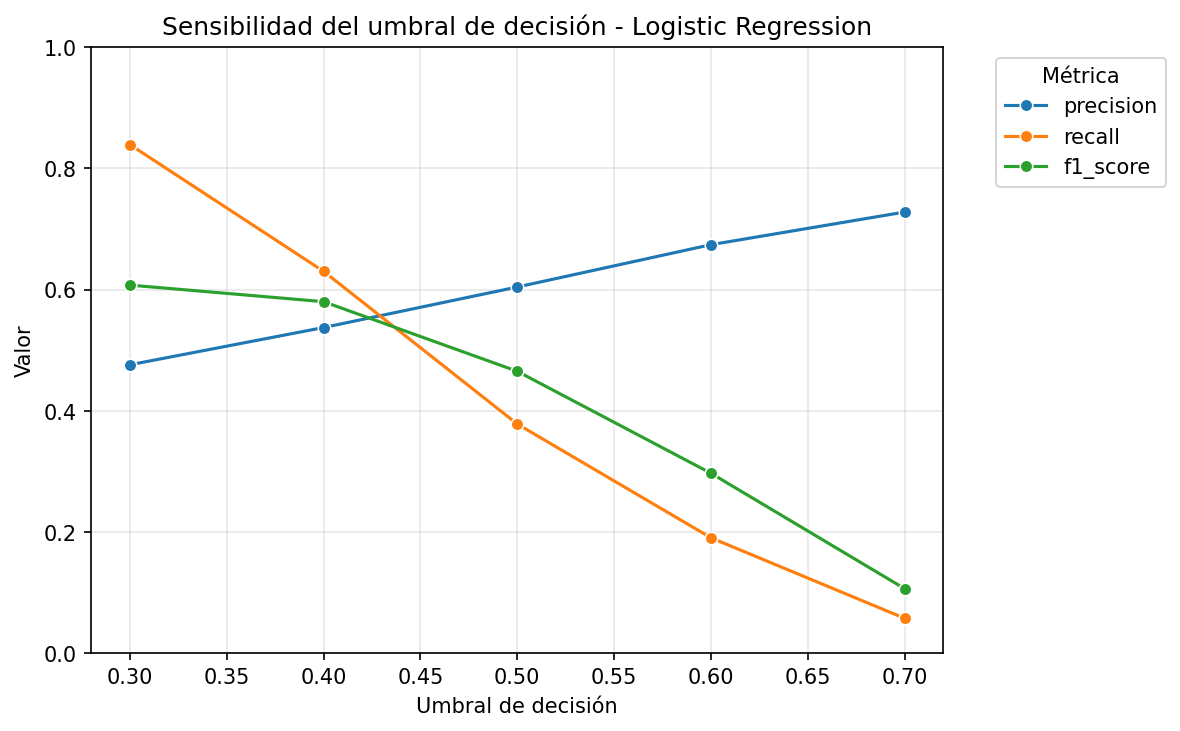

In [9]:
threshold_plot = PLOTS_DIR / "threshold_analysis_classification.png"
if threshold_plot.exists():
    display(Image(filename=str(threshold_plot)))
else:
    print("No se encontró gráfico de threshold:", threshold_plot)

## 7. Resultados finales de regresión

La regresión se evalúa como componente complementario. El objetivo no es reemplazar el análisis de abandono, sino explorar si los modelos permiten estimar `gasto_mensual` con una capacidad explicativa razonable.

In [10]:
print("Métricas base de regresión")
display(redondear(regression_base))

print("Métricas optimizadas de regresión")
display(redondear(regression_optimized))

print("Comparación base vs optimizado")
display(redondear(regression_comparison))

Métricas base de regresión


,modelo,mae,rmse,r2
0,Linear Regression,0.8164,1.0064,-0.0020
1,Decision Tree Regressor,1.1521,1.4263,-1.0127


Métricas optimizadas de regresión


,modelo,mae,rmse,r2
0,Decision Tree Regressor,0.8178,1.0072,-0.0036


Comparación base vs optimizado


,modelo,mae_base,rmse_base,r2_base,mae_optimizado,rmse_optimizado,r2_optimizado,delta_mae,delta_rmse,delta_r2
0,Decision Tree Regressor,1.1521,1.4263,-1.0127,0.8178,1.0072,-0.0036,-0.3343,-0.4191,1.009


In [11]:
# Comparación explícita entre Linear Regression baseline y Decision Tree Regressor optimizado
regresion_final_rows = []

if not regression_base.empty and "Linear Regression" in regression_base["modelo"].values:
    lin = regression_base[regression_base["modelo"] == "Linear Regression"].iloc[0]
    regresion_final_rows.append({
        "tarea": "regresión",
        "modelo": "Linear Regression",
        "version": "base",
        "rol_final": "referencia principal de regresión",
        "criterio": "menor error y mayor R² relativo",
        "mae": lin.get("mae", np.nan),
        "rmse": lin.get("rmse", np.nan),
        "r2": lin.get("r2", np.nan),
        "justificacion": "Se mantiene levemente mejor que el árbol optimizado en MAE, RMSE y R².",
    })

if not regression_optimized.empty and "Decision Tree Regressor" in regression_optimized["modelo"].values:
    tree = regression_optimized[regression_optimized["modelo"] == "Decision Tree Regressor"].iloc[0]
    regresion_final_rows.append({
        "tarea": "regresión",
        "modelo": "Decision Tree Regressor",
        "version": "optimizado",
        "rol_final": "complementario",
        "criterio": "mejora técnica frente al árbol base",
        "mae": tree.get("mae", np.nan),
        "rmse": tree.get("rmse", np.nan),
        "r2": tree.get("r2", np.nan),
        "justificacion": "Mejora mucho frente al árbol base, pero no supera a Linear Regression.",
    })

df_regresion_final = pd.DataFrame(regresion_final_rows)
display(redondear(df_regresion_final))

,tarea,modelo,version,rol_final,criterio,mae,rmse,r2,justificacion
0,regresión,Linear Regression,base,referencia principal de regresión,menor error y mayor R² relativo,0.8164,1.0064,-0.0020,Se mantiene levemente mejor que el árbol optim...
1,regresión,Decision Tree Regressor,optimizado,complementario,mejora técnica frente al árbol base,0.8178,1.0072,-0.0036,"Mejora mucho frente al árbol base, pero no sup..."


### Lectura de regresión

`Decision Tree Regressor` optimizado mejora fuertemente respecto a su versión base. Sin embargo, no supera realmente a `Linear Regression`, que se mantiene levemente mejor en `MAE`, `RMSE` y `R²`.

Además, los valores de `R²` son cercanos a cero o negativos, lo que indica baja capacidad explicativa sobre `gasto_mensual`. Por esta razón, la regresión no debe presentarse como el eje principal del proyecto, sino como un análisis complementario.

## 8. Visualizaciones finales relevantes

En esta sección se cargan algunos gráficos generados en los notebooks anteriores para apoyar la síntesis final.

### classification_base_vs_optimized_by_model.png

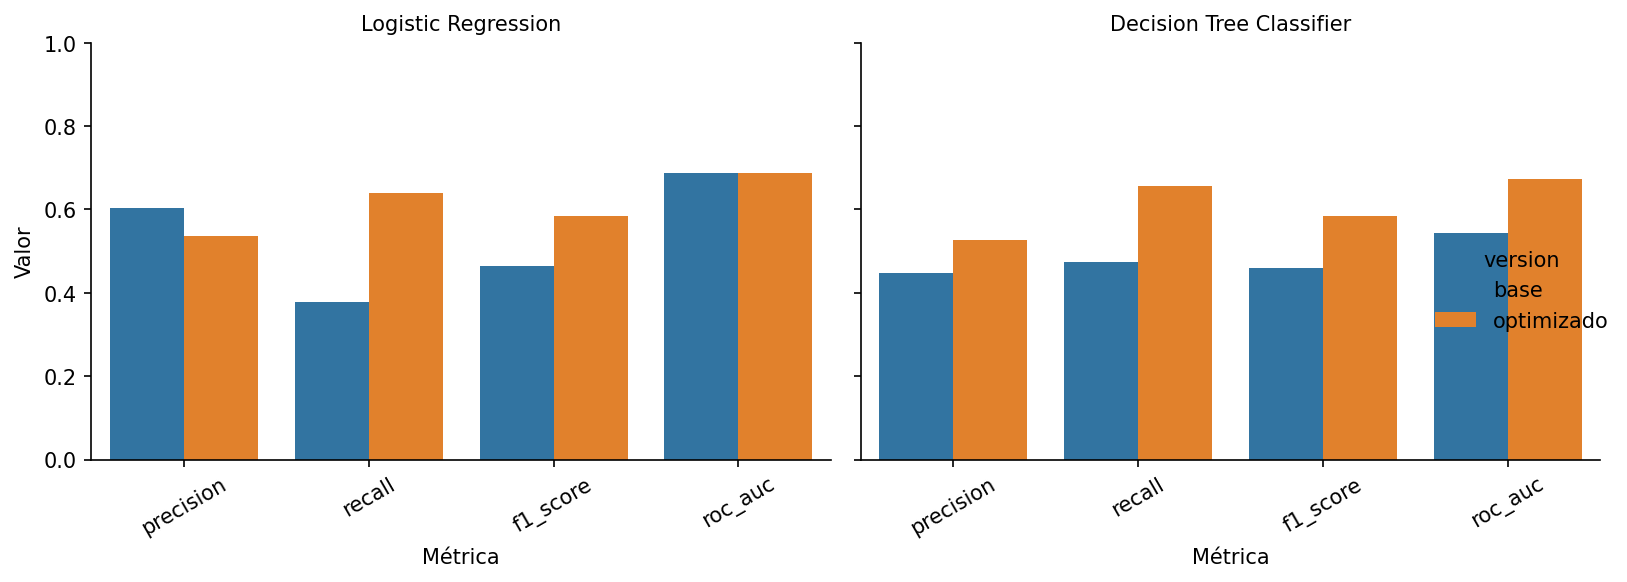

### classification_base_vs_optimized.png

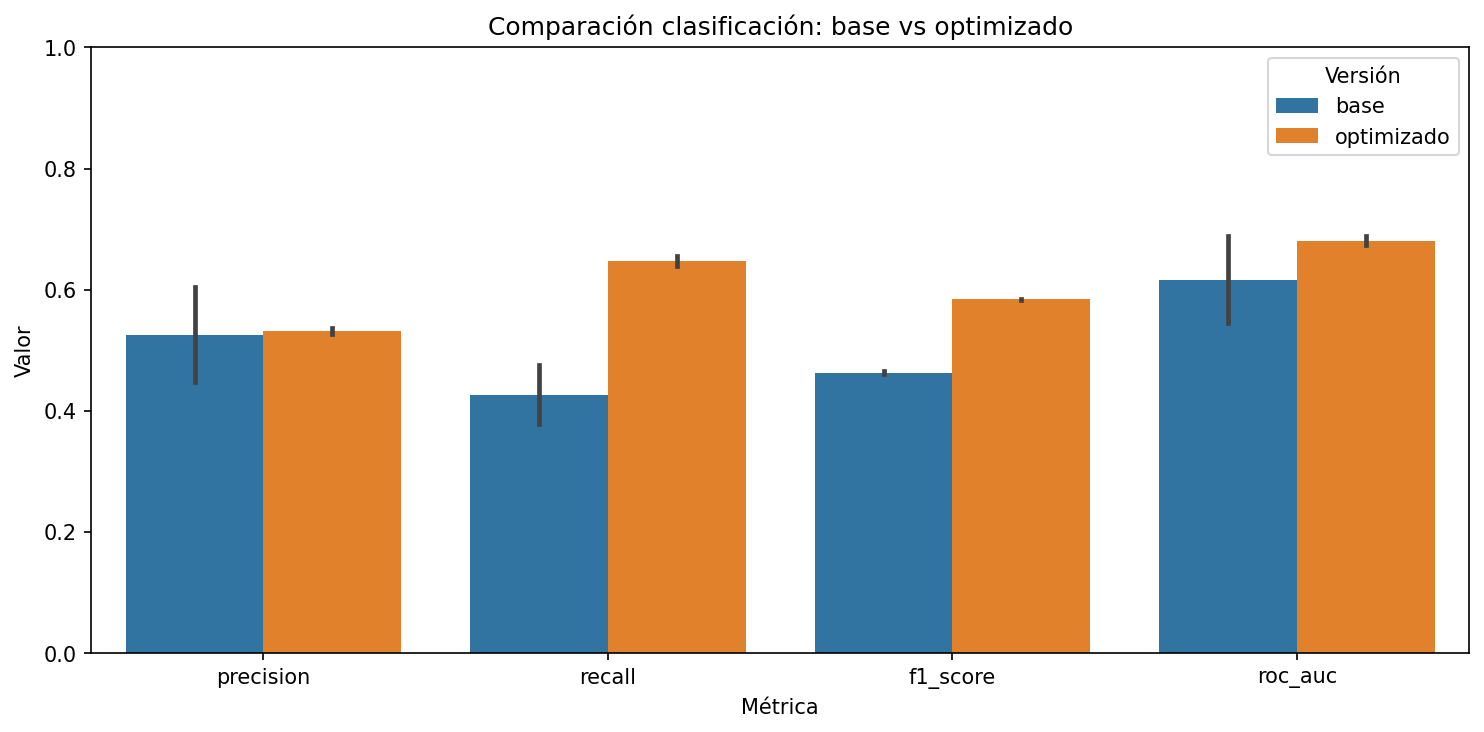

### optimized_confusion_matrix_logistic_regression.png

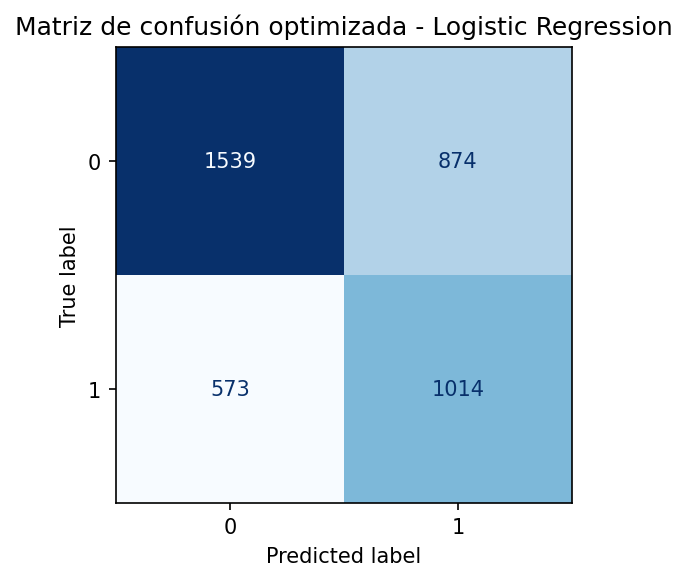

### optimized_confusion_matrix_decision_tree_classifier.png

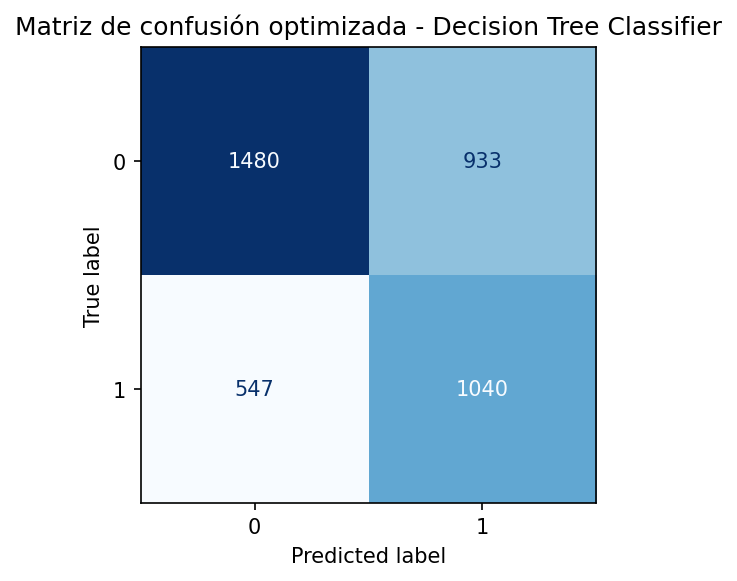

### regression_base_vs_optimized_errors.png

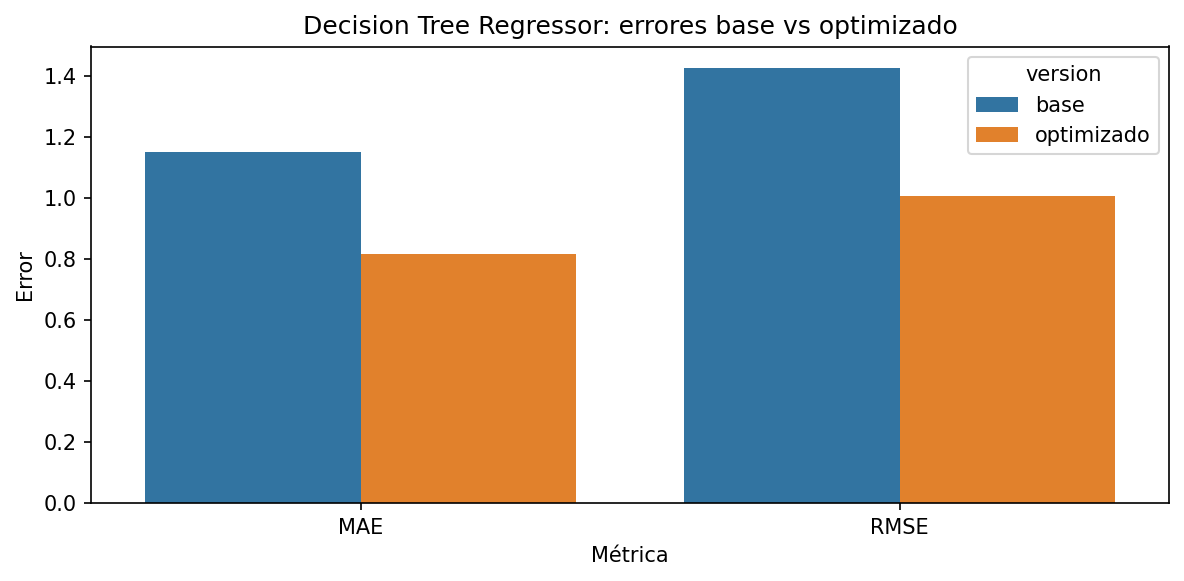

### regression_base_vs_optimized_r2.png

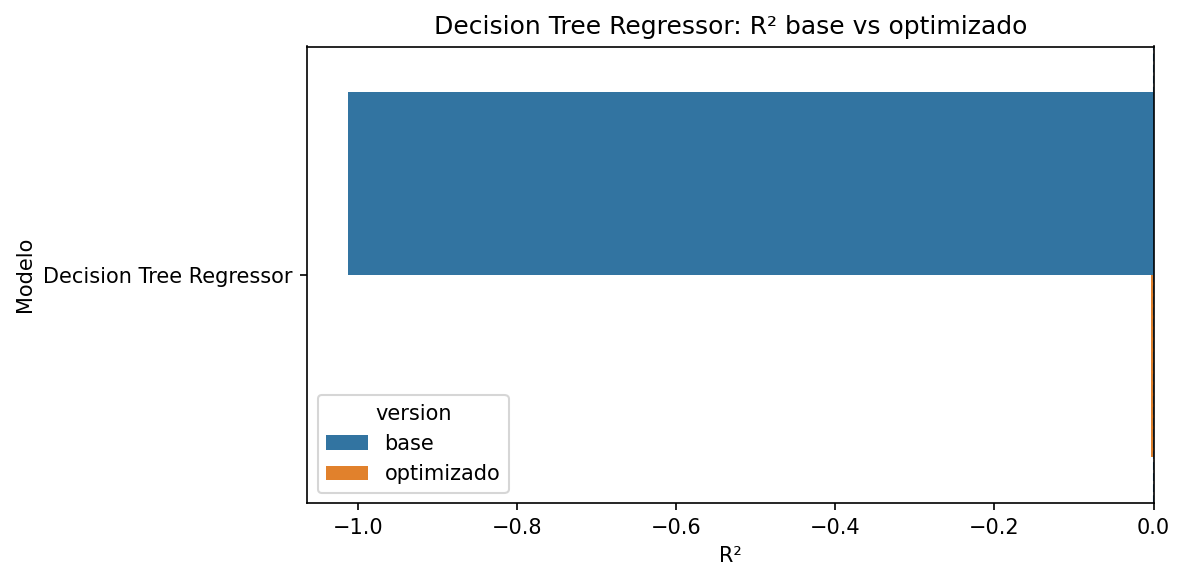

In [12]:
plots_a_mostrar = [
    "classification_base_vs_optimized_by_model.png",
    "classification_base_vs_optimized.png",
    "optimized_confusion_matrix_logistic_regression.png",
    "optimized_confusion_matrix_decision_tree_classifier.png",
    "regression_base_vs_optimized_errors.png",
    "regression_base_vs_optimized_r2.png",
]

for nombre_plot in plots_a_mostrar:
    ruta = PLOTS_DIR / nombre_plot
    if ruta.exists():
        display(Markdown(f"### {nombre_plot}"))
        display(Image(filename=str(ruta)))
    else:
        print("No encontrado:", nombre_plot)

## 9. Selección final de modelos

La selección final no se plantea como un único ganador absoluto. Los resultados muestran distintos modelos adecuados según el criterio de decisión.

In [13]:
# Construcción de tabla final de selección
cols_clf = [
    "tarea", "modelo", "version", "rol_final", "criterio",
    "accuracy", "precision", "recall", "f1_score", "roc_auc", "justificacion"
]
cols_reg = [
    "tarea", "modelo", "version", "rol_final", "criterio",
    "mae", "rmse", "r2", "justificacion"
]

final_model_selection = []

if not df_clasificacion_final.empty:
    final_model_selection.append(df_clasificacion_final)
if not df_regresion_final.empty:
    final_model_selection.append(df_regresion_final)

if final_model_selection:
    df_final_model_selection = pd.concat(final_model_selection, ignore_index=True, sort=False)
else:
    df_final_model_selection = pd.DataFrame()

final_selection_path = METRICS_DIR / "final_model_selection.csv"
df_final_model_selection.to_csv(final_selection_path, index=False)

print("Archivo guardado en:", final_selection_path.relative_to(PROJECT_ROOT))
display(redondear(df_final_model_selection))

Archivo guardado en: results/metrics/final_model_selection.csv


,tarea,modelo,version,rol_final,criterio,accuracy,precision,recall,f1_score,roc_auc,justificacion,mae,rmse,r2
0,clasificación,Logistic Regression,optimizado,recomendado principal,equilibrio general e interpretabilidad,0.6382,0.5371,0.6389,0.5836,0.6883,"Mantiene mayor precision, accuracy y ROC-AUC f...",NaN,NaN,NaN
1,clasificación,Decision Tree Classifier,optimizado,alternativa por recall,mayor detección de abandono,0.6300,0.5271,0.6553,0.5843,0.6737,Obtiene mayor recall y f1_score levemente supe...,NaN,NaN,NaN
2,clasificación,SVM,base,referencia no priorizada,comparación base,0.6445,0.6022,0.3062,0.4060,0.6570,"Presenta ROC-AUC intermedio, pero bajo recall....",NaN,NaN,NaN
3,regresión,Linear Regression,base,referencia principal de regresión,menor error y mayor R² relativo,NaN,NaN,NaN,NaN,NaN,Se mantiene levemente mejor que el árbol optim...,0.8164,1.0064,-0.0020
4,regresión,Decision Tree Regressor,optimizado,complementario,mejora técnica frente al árbol base,NaN,NaN,NaN,NaN,NaN,"Mejora mucho frente al árbol base, pero no sup...",0.8178,1.0072,-0.0036


### Recomendación final

Para clasificación, se recomienda mantener dos lecturas complementarias:

- **Modelo principal recomendado:** `Logistic Regression` optimizado, por equilibrio general, interpretabilidad, mayor `precision`, mayor `accuracy` y mejor `roc_auc`.
- **Modelo alternativo si se prioriza detección de abandono:** `Decision Tree Classifier` optimizado, por su mayor `recall` y `f1_score` levemente superior.

Para regresión, `Linear Regression` se mantiene como referencia principal. `Decision Tree Regressor` optimizado demuestra una mejora técnica importante frente al árbol base, pero no supera a la regresión lineal.

## 10. Limitaciones del análisis

Las principales limitaciones detectadas son:

1. El rendimiento de clasificación es moderado. La optimización mejora la detección de abandono, pero no elimina los trade-offs entre `precision` y `recall`.
2. La elección del umbral depende de criterios de negocio externos, especialmente del costo relativo de falsos positivos y falsos negativos.
3. La regresión sobre `gasto_mensual` presenta baja capacidad explicativa con los modelos evaluados.
4. `SVM` no fue priorizado para optimización por costo computacional, por lo que queda como alternativa exploratoria futura.
5. No se evaluaron modelos más avanzados como Random Forest, Gradient Boosting o XGBoost.
6. La calidad de la predicción podría mejorar con nuevas variables o mayor ingeniería de características.

## 11. Recomendaciones futuras

### Recomendaciones técnicas

- Evaluar modelos ensemble en futuras iteraciones, especialmente Random Forest o Gradient Boosting.
- Probar calibración de probabilidades si se usará el modelo para asignar riesgos.
- Definir el umbral de decisión con costos reales de campaña y retención.
- Explorar nuevas variables que permitan explicar mejor `gasto_mensual`.
- Analizar si SVM optimizado aporta mejoras relevantes si se dispone de mayor tiempo de ejecución.

### Recomendaciones de negocio

- Usar el modelo de abandono como herramienta de priorización, no como decisión automática.
- Definir el costo de contactar clientes que no abandonarían frente al costo de no detectar clientes que sí abandonan.
- Priorizar campañas de retención para segmentos con alto riesgo de abandono y mayor valor económico, siempre considerando las limitaciones de la regresión.

## 12. Conclusión ejecutiva

El proyecto permitió implementar un flujo completo de machine learning supervisado para analizar abandono de clientes y estimar una variable económica complementaria.

En clasificación, la optimización mejoró de manera relevante la detección de clientes que abandonan. `Logistic Regression` optimizado se recomienda como alternativa principal por su equilibrio general, simplicidad e interpretabilidad. `Decision Tree Classifier` optimizado queda como alternativa fuerte cuando se prioriza maximizar la detección de abandono.

En regresión, los modelos evaluados mostraron baja capacidad explicativa sobre `gasto_mensual`. Aunque la optimización mejoró considerablemente el árbol de regresión, no logró superar a `Linear Regression`.

La recomendación final es utilizar el modelo de clasificación optimizado como apoyo para priorizar acciones de retención, considerando que el umbral de decisión debe definirse según criterios de negocio y no únicamente por una métrica técnica.

In [14]:
# Guardar resumen ejecutivo en formato Markdown para apoyar informe/presentación
final_findings = '''# Síntesis final del proyecto

## Clasificación
- Logistic Regression optimizado se recomienda como modelo principal por equilibrio general e interpretabilidad.
- Decision Tree Classifier optimizado queda como alternativa si se prioriza mayor recall.
- La decisión final depende del equilibrio entre detectar abandono y evitar falsas alertas.

## Umbral de decisión
- El threshold no es hiperparámetro técnico.
- Debe definirse según criterios de negocio y costos relativos de falsos positivos/falsos negativos.

## Regresión
- Linear Regression se mantiene como mejor referencia en regresión.
- Decision Tree Regressor optimizado mejora frente a su versión base, pero no supera a Linear Regression.
- La capacidad explicativa sobre gasto_mensual es baja.

## Recomendación
Usar el modelo de clasificación optimizado como herramienta de priorización para acciones de retención, acompañado de una definición de umbral basada en criterios de negocio.
'''

final_findings_path = REPORTS_DIR / "final_findings.md"
final_findings_path.write_text(final_findings, encoding="utf-8")

print("Resumen final guardado en:", final_findings_path.relative_to(PROJECT_ROOT))

Resumen final guardado en: results/reports/final_findings.md


## 13. Comprobación final de archivos generados

In [15]:
archivos_finales = [
    METRICS_DIR / "final_model_selection.csv",
    REPORTS_DIR / "final_findings.md",
]

checks_finales = []
for ruta in archivos_finales:
    checks_finales.append({
        "archivo": str(ruta.relative_to(PROJECT_ROOT)),
        "estado": "OK" if ruta.exists() else "FALTA"
    })

display(pd.DataFrame(checks_finales))

,archivo,estado
0,results/metrics/final_model_selection.csv,OK
1,results/reports/final_findings.md,OK


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=a797108b-ff37-4667-9d30-00c3227a6ce3' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>